# Exploratory Data Analysis

In this notebook, the cleaned Online Retail dataset will be explored to understand sales performance, transaction patterns, product performance, and country-level performance.

The main goals of this notebook are to answer:

- What is the overall sales performance?
- How does revenue change over time?
- Which countries generate the most revenue?
- Which products generate the most revenue?
- What are the main transaction patterns in the dataset?

In [70]:
import pandas as pd
import matplotlib.pyplot as plt

In [71]:
df = pd.read_csv(
    "../data/cleaned/online_retail_cleaned.csv",
    dtype={
        "InvoiceNo": "string",
        "StockCode": "string",
        "CustomerID": "Int64"
    },
    parse_dates=["InvoiceDate"],
    low_memory=False
)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled,HasCustomerID,ProductDescription,TotalPrice,IsHighValueOutlier,IsNonProduct
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,True,WHITE HANGING HEART T-LIGHT HOLDER,15.30,False,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,True,WHITE METAL LANTERN,20.34,False,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,True,CREAM CUPID HEARTS COAT HANGER,22.00,False,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,True,KNITTED UNION FLAG HOT WATER BOTTLE,20.34,False,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,True,RED WOOLLY HOTTIE WHITE HEART.,20.34,False,False


In [72]:
df.shape

(524878, 14)

In [73]:
df.dtypes

InvoiceNo             string[python]
StockCode             string[python]
Description                   object
Quantity                       int64
InvoiceDate           datetime64[ns]
UnitPrice                    float64
CustomerID                     Int64
Country                       object
IsCancelled                     bool
HasCustomerID                   bool
ProductDescription            object
TotalPrice                   float64
IsHighValueOutlier              bool
IsNonProduct                    bool
dtype: object

In [74]:
df.isnull().sum()

InvoiceNo                  0
StockCode                  0
Description                0
Quantity                   0
InvoiceDate                0
UnitPrice                  0
CustomerID            132186
Country                    0
IsCancelled                0
HasCustomerID              0
ProductDescription         0
TotalPrice                 0
IsHighValueOutlier         0
IsNonProduct               0
dtype: int64

## Dataset Overview

The cleaned dataset is loaded from `data/cleaned/online_retail_cleaned.csv`.

This dataset was prepared in the previous notebook by removing duplicates, cancelled transactions, negative quantities, and invalid prices. Additional columns were also created to support analysis, including `TotalPrice`, `HasCustomerID`, `ProductDescription`, `IsHighValueOutlier`, and `IsNonProduct`.

## Creating Date Features

Additional date columns will be created from `InvoiceDate` to support time-based analysis such as monthly revenue trends and daily transaction patterns.

In [75]:
df['InvoiceYear'] = df['InvoiceDate'].dt.year
df['InvoiceMonth'] = df['InvoiceDate'].dt.month
df['InvoiceYearMonth'] = df['InvoiceDate'].dt.to_period('M').astype(str)
df['InvoiceDay'] = df['InvoiceDate'].dt.day_name()
df['InvoiceHour'] = df['InvoiceDate'].dt.hour

df[['InvoiceDate', 'InvoiceYear', 'InvoiceMonth', 'InvoiceYearMonth', 'InvoiceDay', 'InvoiceHour']].head()

,InvoiceDate,InvoiceYear,InvoiceMonth,InvoiceYearMonth,InvoiceDay,InvoiceHour
0,2010-12-01 08:26:00,2010,12,2010-12,Wednesday,8
1,2010-12-01 08:26:00,2010,12,2010-12,Wednesday,8
2,2010-12-01 08:26:00,2010,12,2010-12,Wednesday,8
3,2010-12-01 08:26:00,2010,12,2010-12,Wednesday,8
4,2010-12-01 08:26:00,2010,12,2010-12,Wednesday,8


### Date Feature Result

New date-based columns were created from `InvoiceDate`.

These columns will support time-based analysis, including monthly revenue trends, daily transaction patterns, and hourly purchasing behavior.

The created columns are:

- `InvoiceYear`
- `InvoiceMonth`
- `InvoiceYearMonth`
- `InvoiceDay`
- `InvoiceHour`

## Overall Sales KPIs

The first step in the exploratory analysis is to calculate high-level sales performance indicators.

These KPIs provide a general overview of the cleaned dataset before exploring trends by month, country, and product.

In [76]:
total_revenue = df['TotalPrice'].sum()
total_quantity = df['Quantity'].sum()
total_invoices = df['InvoiceNo'].nunique()
total_products = df['StockCode'].nunique()
total_customers = df['CustomerID'].nunique()
total_countries = df['Country'].nunique()

kpi_summary = pd.DataFrame({
    'Metric': [
        'Total Revenue',
        'Total Quantity Sold',
        'Unique Invoices',
        'Unique Products',
        'Unique Customers',
        'Countries'
    ],
    'Value': [
        total_revenue,
        total_quantity,
        total_invoices,
        total_products,
        total_customers,
        total_countries
    ]
})

kpi_summary

,Metric,Value
0,Total Revenue,1.064211e+07
1,Total Quantity Sold,5.572420e+06
2,Unique Invoices,1.996000e+04
3,Unique Products,3.922000e+03
4,Unique Customers,4.338000e+03
5,Countries,3.800000e+01


In [77]:
kpi_summary_formatted = kpi_summary.copy()

kpi_summary_formatted['Value'] = kpi_summary_formatted['Value'].apply(
    lambda x: f"{x:,.2f}" if isinstance(x, float) else f"{x:,}"
)

kpi_summary_formatted

,Metric,Value
0,Total Revenue,"10,642,110.80"
1,Total Quantity Sold,"5,572,420.00"
2,Unique Invoices,"19,960.00"
3,Unique Products,"3,922.00"
4,Unique Customers,"4,338.00"
5,Countries,38.00


### Overall Sales KPI Observations

The cleaned dataset contains 19,960 unique invoices across 38 countries.

The total revenue in the cleaned dataset is 10,642,110.80, with a total quantity sold of 5,572,420 units.

The dataset includes 3,922 unique products and 4,338 identifiable customers.

These KPIs provide a high-level overview of the cleaned sales data before exploring revenue trends, country performance, and product performance in more detail.

## Monthly Revenue Trend

Monthly revenue will be analyzed to understand how sales changed over time.

This helps identify sales growth, seasonal patterns, and months with unusually high or low revenue.

In [79]:
monthly_revenue = (
    df
    .groupby('InvoiceYearMonth')['TotalPrice']
    .sum()
    .reset_index()
)

monthly_revenue

,InvoiceYearMonth,TotalPrice
0,2010-12,821452.730
1,2011-01,689811.610
2,2011-02,522545.560
3,2011-03,716215.260
4,2011-04,536968.491
5,2011-05,769296.610
6,2011-06,760547.010
7,2011-07,718076.121
8,2011-08,757841.380
9,2011-09,1056435.192


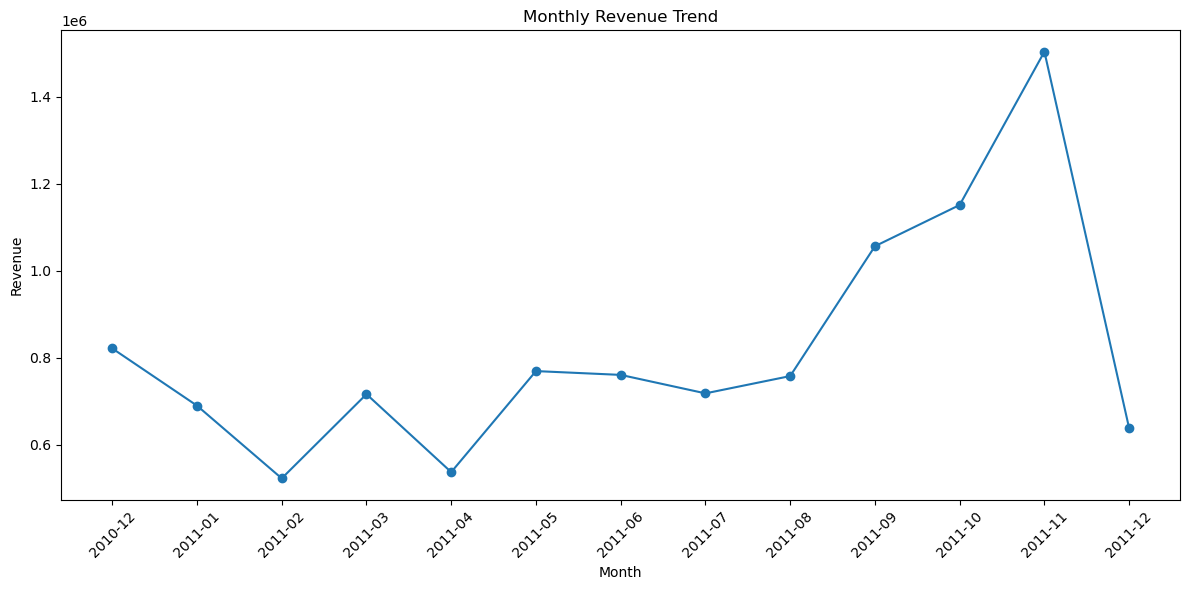

In [80]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue['InvoiceYearMonth'], monthly_revenue['TotalPrice'], marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Monthly Revenue Observations

Monthly revenue increased noticeably toward the end of 2011.

The highest revenue month was November 2011, with total revenue of 1,503,866.78. October 2011 and September 2011 were also strong months, suggesting a possible seasonal increase before the end-of-year shopping period.

February 2011 had the lowest revenue among the complete months, with total revenue of 522,545.56.

December 2011 should be interpreted carefully because the dataset only includes transactions up to December 9, 2011. Therefore, December 2011 does not represent a full month and should not be directly compared with complete months.

In [81]:
monthly_revenue.sort_values('TotalPrice', ascending=False)

,InvoiceYearMonth,TotalPrice
11,2011-11,1503866.780
10,2011-10,1151263.730
9,2011-09,1056435.192
0,2010-12,821452.730
5,2011-05,769296.610
6,2011-06,760547.010
8,2011-08,757841.380
7,2011-07,718076.121
3,2011-03,716215.260
1,2011-01,689811.610


In [82]:
monthly_revenue[monthly_revenue['InvoiceYearMonth'] != '2011-12'].sort_values('TotalPrice').head(1)

,InvoiceYearMonth,TotalPrice
2,2011-02,522545.56


## Country Revenue Analysis

Country-level revenue will be analyzed to understand which countries contribute the most sales.

Since the dataset is from a UK-based online retailer, the United Kingdom is expected to represent the largest share of revenue.

In [83]:
country_revenue = (
    df
    .groupby('Country')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

country_revenue.head(10)

,Country,TotalPrice
0,United Kingdom,9001744.094
1,Netherlands,285446.340
2,EIRE,283140.520
3,Germany,228678.400
4,France,209625.370
5,Australia,138453.810
6,Spain,61558.560
7,Switzerland,57067.600
8,Belgium,41196.340
9,Sweden,38367.830


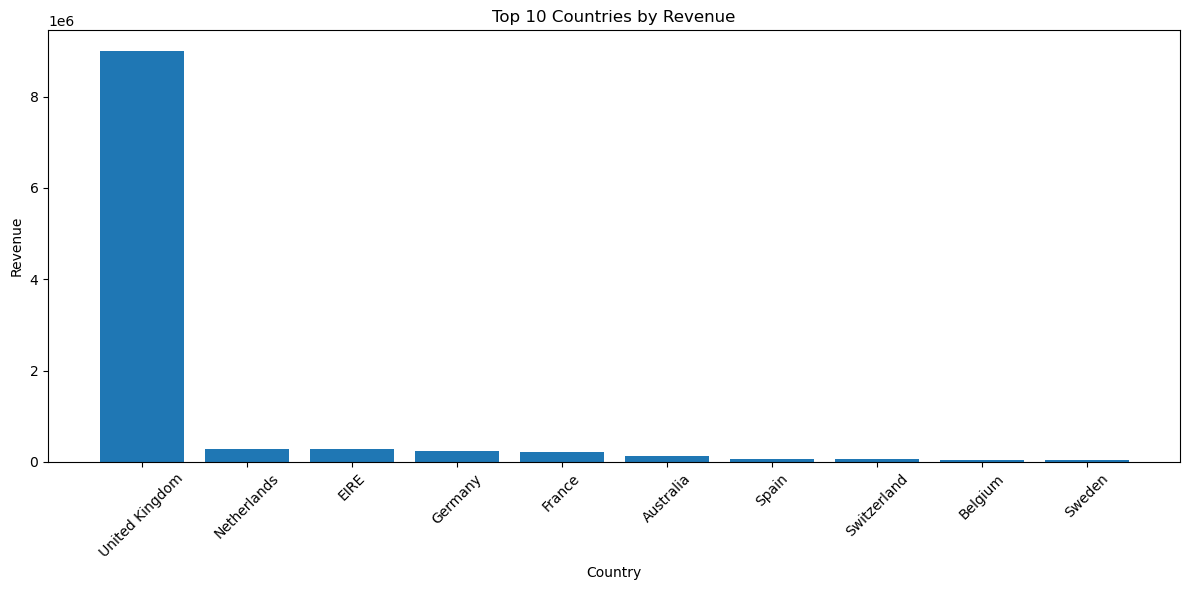

In [84]:
top_10_countries = country_revenue.head(10)

plt.figure(figsize=(12, 6))
plt.bar(top_10_countries['Country'], top_10_countries['TotalPrice'])
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Country Revenue Observations

The United Kingdom generated the highest revenue by a very large margin, with total revenue of 9,001,744.09.

The next highest countries were the Netherlands, EIRE, Germany, and France, but their revenue values were much smaller compared with the United Kingdom.

This confirms that the dataset is heavily concentrated in the UK market. Because of this imbalance, country-level insights should be interpreted carefully. In later analysis, it may be useful to compare the United Kingdom separately from non-UK countries.

In [85]:
country_revenue['RevenueShare'] = country_revenue['TotalPrice'] / country_revenue['TotalPrice'].sum() * 100

country_revenue.head(10)

,Country,TotalPrice,RevenueShare
0,United Kingdom,9001744.094,84.586078
1,Netherlands,285446.340,2.682234
2,EIRE,283140.520,2.660567
3,Germany,228678.400,2.148807
4,France,209625.370,1.969772
5,Australia,138453.810,1.301000
6,Spain,61558.560,0.578443
7,Switzerland,57067.600,0.536243
8,Belgium,41196.340,0.387107
9,Sweden,38367.830,0.360528


In [86]:
country_revenue_formatted = country_revenue.copy()

country_revenue_formatted['TotalPrice'] = country_revenue_formatted['TotalPrice'].apply(lambda x: f"{x:,.2f}")
country_revenue_formatted['RevenueShare'] = country_revenue_formatted['RevenueShare'].apply(lambda x: f"{x:.2f}%")

country_revenue_formatted.head(10)

,Country,TotalPrice,RevenueShare
0,United Kingdom,"9,001,744.09",84.59%
1,Netherlands,"285,446.34",2.68%
2,EIRE,"283,140.52",2.66%
3,Germany,"228,678.40",2.15%
4,France,"209,625.37",1.97%
5,Australia,"138,453.81",1.30%
6,Spain,"61,558.56",0.58%
7,Switzerland,"57,067.60",0.54%
8,Belgium,"41,196.34",0.39%
9,Sweden,"38,367.83",0.36%


### Country Revenue Share Observations

The United Kingdom accounts for 84.59% of total revenue, confirming that the dataset is highly concentrated in the UK market.

The next largest markets are much smaller. The Netherlands contributes 2.68%, EIRE contributes 2.66%, Germany contributes 2.15%, and France contributes 1.97%.

This shows that while the dataset includes 38 countries, most revenue comes from one main market. Because of this, later analysis may separate UK and non-UK sales to better understand international performance.

## Top Products by Revenue

Product-level revenue will be analyzed to identify which products generated the highest sales value.

Rows flagged as non-product transactions will be excluded from this analysis because postage, fees, manual adjustments, and similar records can distort product performance.

In [87]:
product_df = df[df['IsNonProduct'] == False]

top_products_revenue = (
    product_df
    .groupby(['StockCode', 'ProductDescription'])['TotalPrice']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

top_products_revenue.head(10)

,StockCode,ProductDescription,TotalPrice
0,22423,REGENCY CAKESTAND 3 TIER,174156.54
1,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60
2,85123A,WHITE HANGING HEART T-LIGHT HOLDER,104462.75
3,47566,PARTY BUNTING,99445.23
4,85099B,JUMBO BAG RED RETROSPOT,94159.81
5,23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92
6,23084,RABBIT NIGHT LIGHT,66870.03
7,22086,PAPER CHAIN KIT 50'S CHRISTMAS,64875.59
8,84879,ASSORTED COLOUR BIRD ORNAMENT,58927.62
9,79321,CHILLI LIGHTS,54096.36


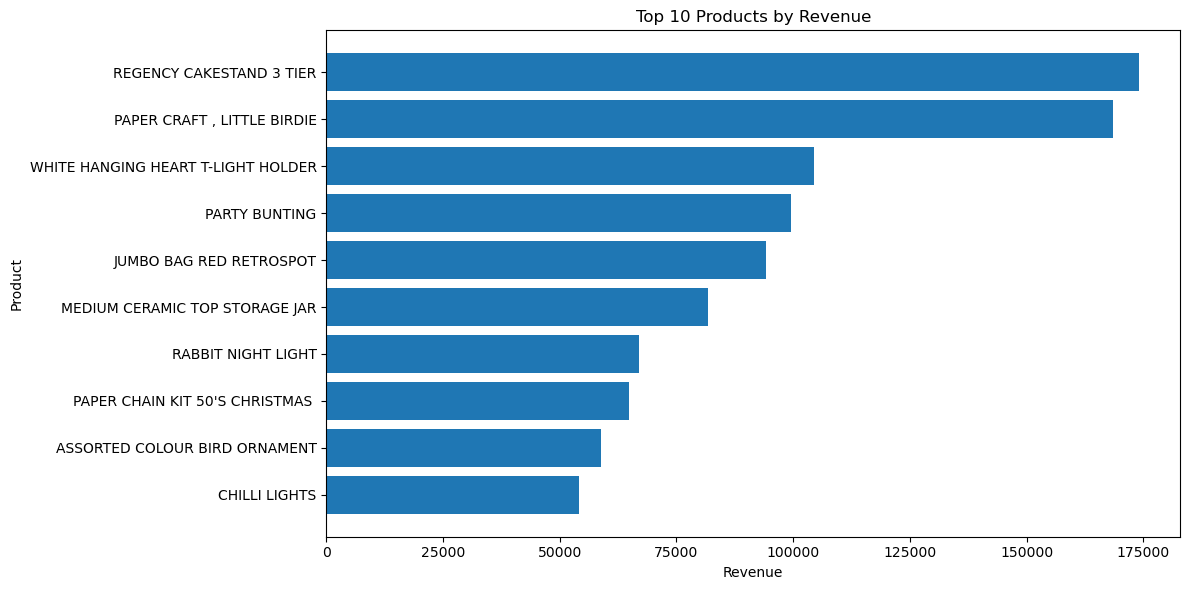

In [88]:
top_10_products_revenue = top_products_revenue.head(10)

plt.figure(figsize=(12, 6))
plt.barh(top_10_products_revenue['ProductDescription'], top_10_products_revenue['TotalPrice'])
plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Top Products by Revenue Observations

After excluding non-product transaction rows, the highest revenue-generating product is `REGENCY CAKESTAND 3 TIER`, with total revenue of 174,156.54.

Other high-revenue products include `PAPER CRAFT, LITTLE BIRDIE`, `WHITE HANGING HEART T-LIGHT HOLDER`, `PARTY BUNTING`, and `JUMBO BAG RED RETROSPOT`.

Some products may appear in the top revenue list because of very large bulk purchases rather than consistently high sales volume. Therefore, product performance should also be analyzed by quantity sold.

In [89]:
top_products_quantity = (
    product_df
    .groupby(['StockCode', 'ProductDescription'])['Quantity']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

top_products_quantity.head(10)

,StockCode,ProductDescription,Quantity
0,23843,"PAPER CRAFT , LITTLE BIRDIE",80995
1,23166,MEDIUM CERAMIC TOP STORAGE JAR,78033
2,22197,POPCORN HOLDER,56898
3,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951
4,85099B,JUMBO BAG RED RETROSPOT,48371
5,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37641
6,21212,PACK OF 72 RETROSPOT CAKE CASES,36396
7,84879,ASSORTED COLOUR BIRD ORNAMENT,36362
8,23084,RABBIT NIGHT LIGHT,30739
9,22492,MINI PAINT SET VINTAGE,26633


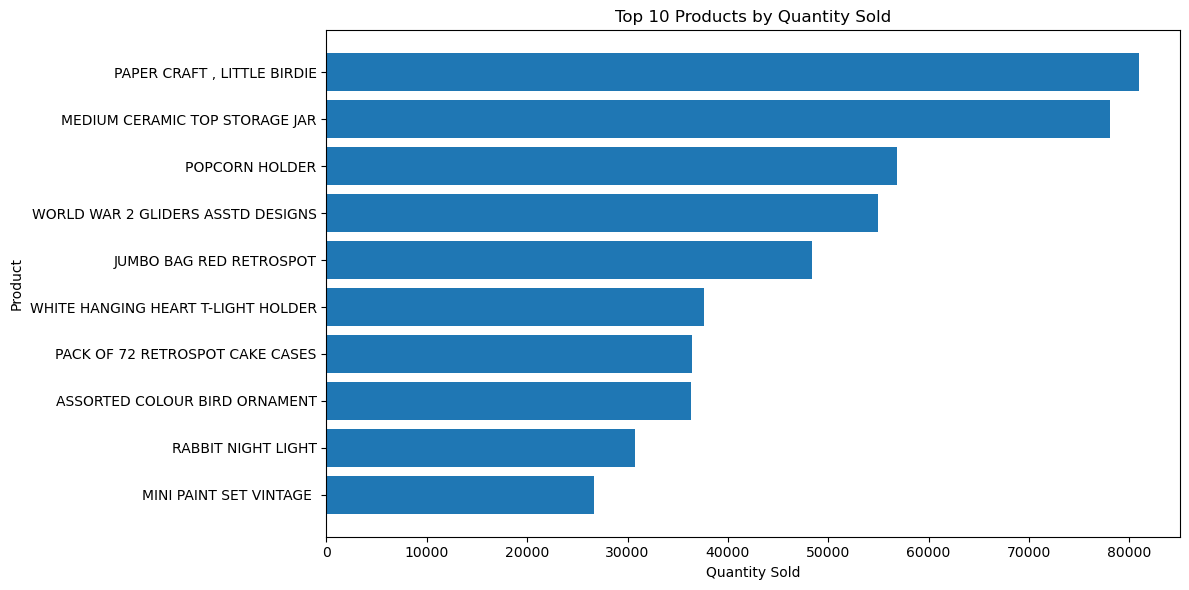

In [90]:
top_10_products_quantity = top_products_quantity.head(10)

plt.figure(figsize=(12, 6))
plt.barh(top_10_products_quantity['ProductDescription'], top_10_products_quantity['Quantity'])
plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Quantity Sold')
plt.ylabel('Product')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Top Products by Quantity Observations

The product with the highest total quantity sold is `PAPER CRAFT, LITTLE BIRDIE`, with 80,995 units sold.

Other high-volume products include `MEDIUM CERAMIC TOP STORAGE JAR`, `POPCORN HOLDER`, `WORLD WAR 2 GLIDERS ASSTD DESIGNS`, and `JUMBO BAG RED RETROSPOT`.

Some products may appear at the top because of very large bulk purchases. Therefore, product performance should be interpreted using multiple measures, including revenue, quantity sold, and number of invoices.

## Top Products by Number of Invoices

Product popularity will also be analyzed by counting the number of unique invoices each product appears in.

This helps identify products that were purchased frequently across many transactions, rather than products that only appear at the top because of one or two large bulk orders.

In [91]:
top_products_invoices = (
    product_df
    .groupby(['StockCode', 'ProductDescription'])['InvoiceNo']
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'InvoiceNo': 'InvoiceCount'})
)

top_products_invoices.head(10)

,StockCode,ProductDescription,InvoiceCount
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2198
1,85099B,JUMBO BAG RED RETROSPOT,2089
2,22423,REGENCY CAKESTAND 3 TIER,1988
3,47566,PARTY BUNTING,1685
4,20725,LUNCH BAG RED RETROSPOT,1565
5,84879,ASSORTED COLOUR BIRD ORNAMENT,1455
6,22197,POPCORN HOLDER,1392
7,22720,SET OF 3 CAKE TINS PANTRY DESIGN,1385
8,21212,PACK OF 72 RETROSPOT CAKE CASES,1320
9,22383,LUNCH BAG SUKI DESIGN,1284


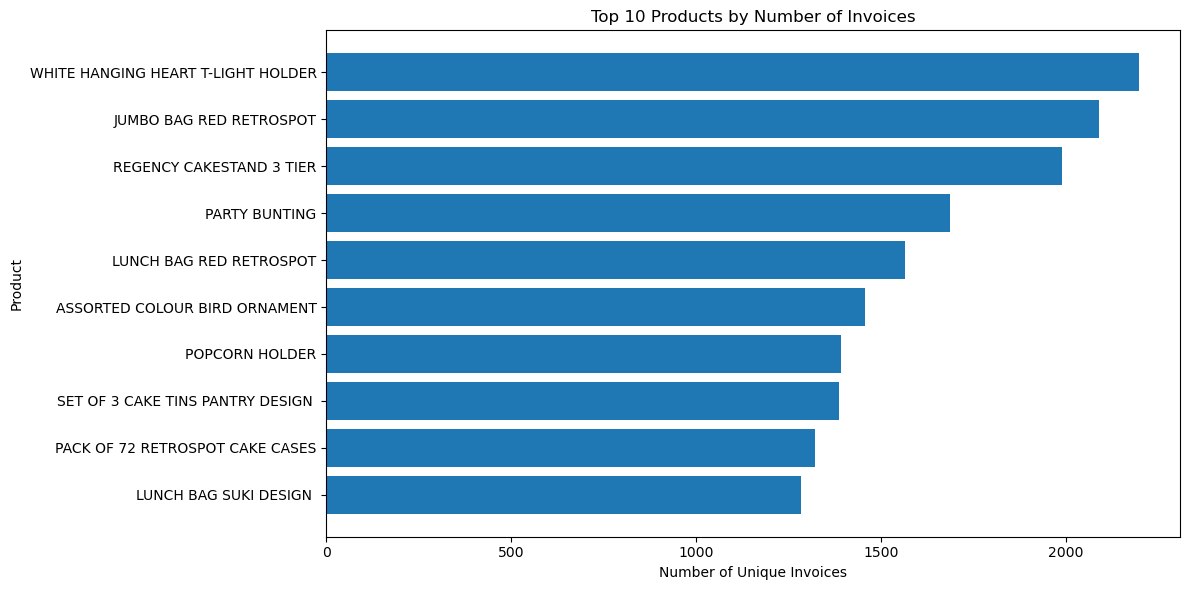

In [92]:
top_10_products_invoices = top_products_invoices.head(10)

plt.figure(figsize=(12, 6))
plt.barh(top_10_products_invoices['ProductDescription'], top_10_products_invoices['InvoiceCount'])
plt.title('Top 10 Products by Number of Invoices')
plt.xlabel('Number of Unique Invoices')
plt.ylabel('Product')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### Top Products by Number of Invoices Observations

The product that appears in the highest number of unique invoices is `WHITE HANGING HEART T-LIGHT HOLDER`, appearing in 2,198 invoices.

Other frequently ordered products include `JUMBO BAG RED RETROSPOT`, `REGENCY CAKESTAND 3 TIER`, `PARTY BUNTING`, and `LUNCH BAG RED RETROSPOT`.

This view is useful because it shows product popularity across many invoices, rather than only measuring total revenue or total quantity sold. Products that appear in many invoices may be more consistently popular with customers.

## Combined Product Performance

A combined product performance table will be created to compare products across multiple measures:

- Total revenue
- Total quantity sold
- Number of unique invoices

This gives a more balanced view of product performance than using only one metric.

In [93]:
product_performance = (
    product_df
    .groupby(['StockCode', 'ProductDescription'])
    .agg(
        TotalRevenue=('TotalPrice', 'sum'),
        TotalQuantity=('Quantity', 'sum'),
        InvoiceCount=('InvoiceNo', 'nunique')
    )
    .reset_index()
)

product_performance.head()

,StockCode,ProductDescription,TotalRevenue,TotalQuantity,InvoiceCount
0,10002,INFLATABLE POLITICAL GLOBE,759.89,860,71
1,10080,GROOVY CACTUS INFLATABLE,119.09,303,22
2,10120,DOGGY RUBBER,40.32,192,29
3,10123C,HEARTS WRAPPING TAPE,3.25,5,3
4,10124A,SPOTS ON RED BOOKCOVER TAPE,6.72,16,5


In [94]:
product_performance.sort_values('TotalRevenue', ascending=False).head(10)

,StockCode,ProductDescription,TotalRevenue,TotalQuantity,InvoiceCount
1310,22423,REGENCY CAKESTAND 3 TIER,174156.54,13851,1988
2465,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
3407,85123A,WHITE HANGING HEART T-LIGHT HOLDER,104462.75,37641,2198
2670,47566,PARTY BUNTING,99445.23,18283,1685
3387,85099B,JUMBO BAG RED RETROSPOT,94159.81,48371,2089
2020,23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247
1942,23084,RABBIT NIGHT LIGHT,66870.03,30739,994
1006,22086,PAPER CHAIN KIT 50'S CHRISTMAS,64875.59,19329,1160
3194,84879,ASSORTED COLOUR BIRD ORNAMENT,58927.62,36362,1455
2845,79321,CHILLI LIGHTS,54096.36,10302,661


In [95]:
product_performance['RevenueRank'] = product_performance['TotalRevenue'].rank(ascending=False)
product_performance['QuantityRank'] = product_performance['TotalQuantity'].rank(ascending=False)
product_performance['InvoiceRank'] = product_performance['InvoiceCount'].rank(ascending=False)

product_performance.sort_values('RevenueRank').head(10)

,StockCode,ProductDescription,TotalRevenue,TotalQuantity,InvoiceCount,RevenueRank,QuantityRank,InvoiceRank
1310,22423,REGENCY CAKESTAND 3 TIER,174156.54,13851,1988,1.0,39.0,3.0
2465,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1,2.0,1.0,3837.0
3407,85123A,WHITE HANGING HEART T-LIGHT HOLDER,104462.75,37641,2198,3.0,6.0,1.0
2670,47566,PARTY BUNTING,99445.23,18283,1685,4.0,22.0,4.0
3387,85099B,JUMBO BAG RED RETROSPOT,94159.81,48371,2089,5.0,5.0,2.0
2020,23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247,6.0,2.0,613.5
1942,23084,RABBIT NIGHT LIGHT,66870.03,30739,994,7.0,9.0,36.0
1006,22086,PAPER CHAIN KIT 50'S CHRISTMAS,64875.59,19329,1160,8.0,20.0,19.0
3194,84879,ASSORTED COLOUR BIRD ORNAMENT,58927.62,36362,1455,9.0,8.0,6.0
2845,79321,CHILLI LIGHTS,54096.36,10302,661,10.0,84.0,106.5


### Combined Product Performance Observations

The combined product performance table compares products using three measures: total revenue, total quantity sold, and number of unique invoices.

This gives a more balanced view of product performance than using only one metric.

`REGENCY CAKESTAND 3 TIER` is the top product by revenue and also appears in many invoices, making it a strong overall performer.

`PAPER CRAFT, LITTLE BIRDIE` ranks highly by revenue and quantity, but it appears in only one invoice. This suggests that its performance may be driven by a single large bulk order rather than consistent customer demand.

`WHITE HANGING HEART T-LIGHT HOLDER` and `JUMBO BAG RED RETROSPOT` perform well across revenue, quantity, and invoice count, suggesting they are consistently popular products.

Overall, product performance should be evaluated using multiple metrics instead of relying only on revenue or quantity.

## Sales by Day of the Week

Revenue will be analyzed by day of the week to understand which days generate the highest sales.

This can help identify weekly sales patterns and customer purchasing behavior.

In [96]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

daily_revenue = (
    df
    .groupby('InvoiceDay')['TotalPrice']
    .sum()
    .reindex(day_order)
    .reset_index()
)

daily_revenue

,InvoiceDay,TotalPrice
0,Monday,1775782.071
1,Tuesday,2175700.511
2,Wednesday,1847074.380
3,Thursday,2199292.570
4,Friday,1837470.491
5,Saturday,NaN
6,Sunday,806790.781


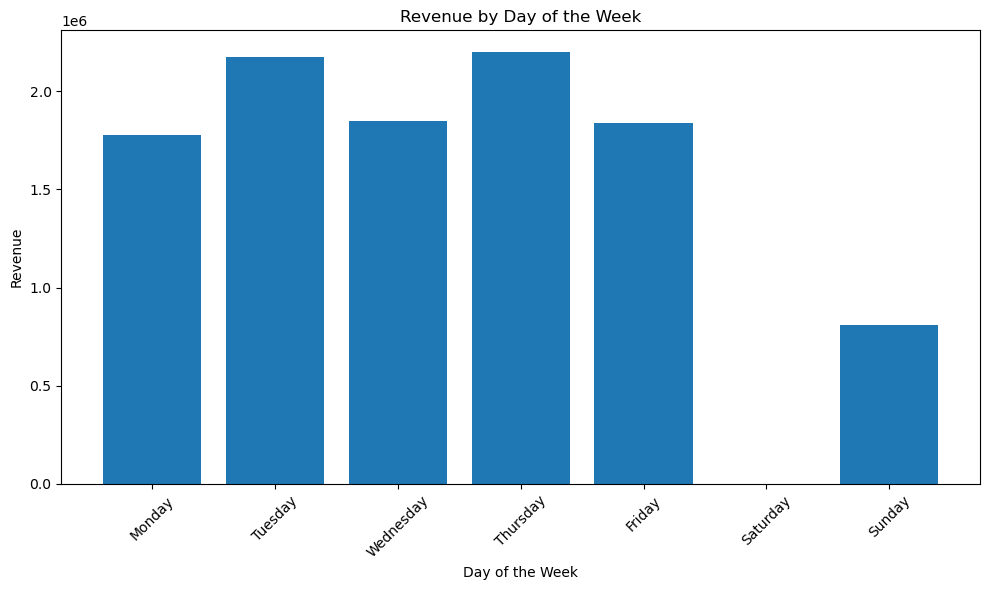

In [97]:
plt.figure(figsize=(10, 6))
plt.bar(daily_revenue['InvoiceDay'], daily_revenue['TotalPrice'])
plt.title('Revenue by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Revenue by Day Observations

Thursday generated the highest revenue, with total sales of 2,199,292.57.

Tuesday was the second strongest day, with total sales of 2,175,700.51.

Sunday had the lowest revenue among active sales days, with total sales of 806,790.78.

There are no Saturday transactions in the cleaned dataset, which may indicate that the business did not process online retail transactions on Saturdays or that Saturday records are not present in the dataset.

Overall, sales activity appears stronger during weekdays, especially Tuesday and Thursday.

## Sales by Hour of the Day

Revenue will be analyzed by hour of the day to identify the most active sales periods.

This helps understand when transactions are most commonly recorded.

In [98]:
hourly_revenue = (
    df
    .groupby('InvoiceHour')['TotalPrice']
    .sum()
    .reset_index()
)

hourly_revenue

,InvoiceHour,TotalPrice
0,6,4.250
1,7,31059.210
2,8,283750.680
3,9,990054.991
4,10,1444814.771
5,11,1236573.290
6,12,1439324.660
7,13,1261195.200
8,14,1177907.521
9,15,1350333.310


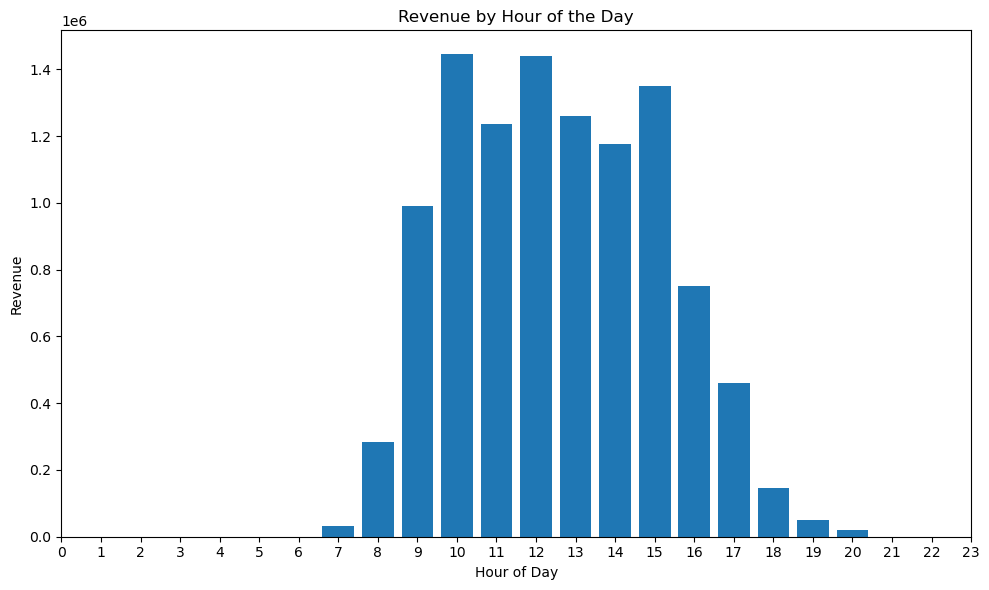

In [99]:
plt.figure(figsize=(10, 6))
plt.bar(hourly_revenue['InvoiceHour'], hourly_revenue['TotalPrice'])
plt.title('Revenue by Hour of the Day')
plt.xlabel('Hour of Day')
plt.ylabel('Revenue')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

In [100]:
hourly_revenue = (
    df
    .groupby('InvoiceHour')['TotalPrice']
    .sum()
    .reindex(range(24), fill_value=0)
    .reset_index()
)

hourly_revenue.columns = ['InvoiceHour', 'TotalPrice']

hourly_revenue

,InvoiceHour,TotalPrice
0,0,0.000
1,1,0.000
2,2,0.000
3,3,0.000
4,4,0.000
5,5,0.000
6,6,4.250
7,7,31059.210
8,8,283750.680
9,9,990054.991


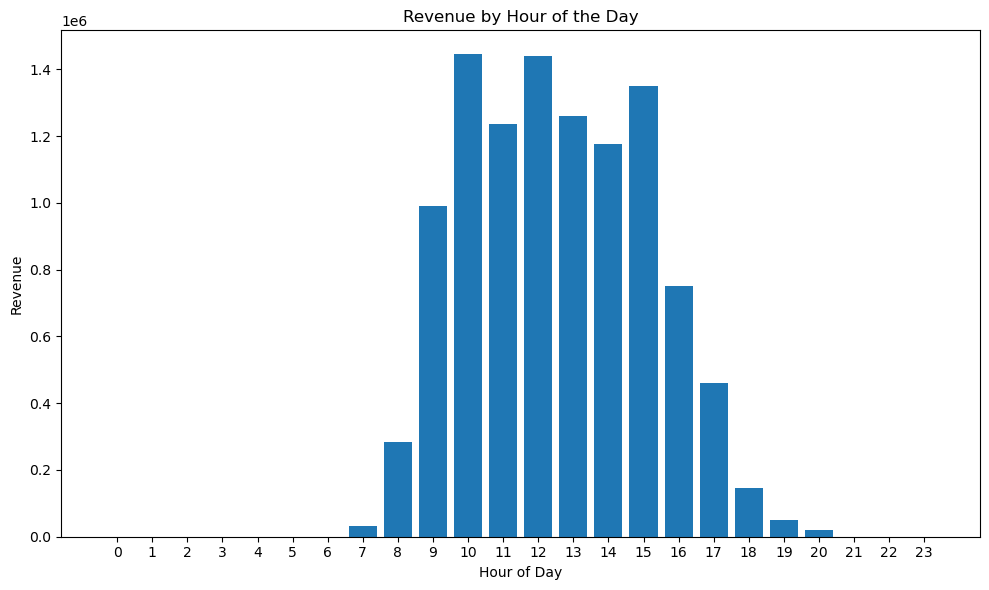

In [101]:
plt.figure(figsize=(10, 6))
plt.bar(hourly_revenue['InvoiceHour'], hourly_revenue['TotalPrice'])
plt.title('Revenue by Hour of the Day')
plt.xlabel('Hour of Day')
plt.ylabel('Revenue')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

### Revenue by Hour Observations

Revenue is concentrated during daytime hours, especially between 9:00 and 15:00.

The highest revenue hour is 10:00, followed closely by 12:00 and 15:00.

Very early and late hours show much lower revenue, and there are no recorded transactions for several overnight hours.

This suggests that transactions in the dataset are mostly recorded during regular business hours rather than evenly throughout the day.

## Invoice Activity by Hour

The number of unique invoices per hour will be analyzed to understand transaction activity separately from revenue.

This helps identify whether high-revenue hours are also high-activity hours, or whether they are influenced by a smaller number of large orders.

In [102]:
hourly_invoice_count = (
    df
    .groupby('InvoiceHour')['InvoiceNo']
    .nunique()
    .reindex(range(24), fill_value=0)
    .reset_index()
)

hourly_invoice_count.columns = ['InvoiceHour', 'InvoiceCount']

hourly_invoice_count

,InvoiceHour,InvoiceCount
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0
5,5,0
6,6,1
7,7,29
8,8,566
9,9,1484


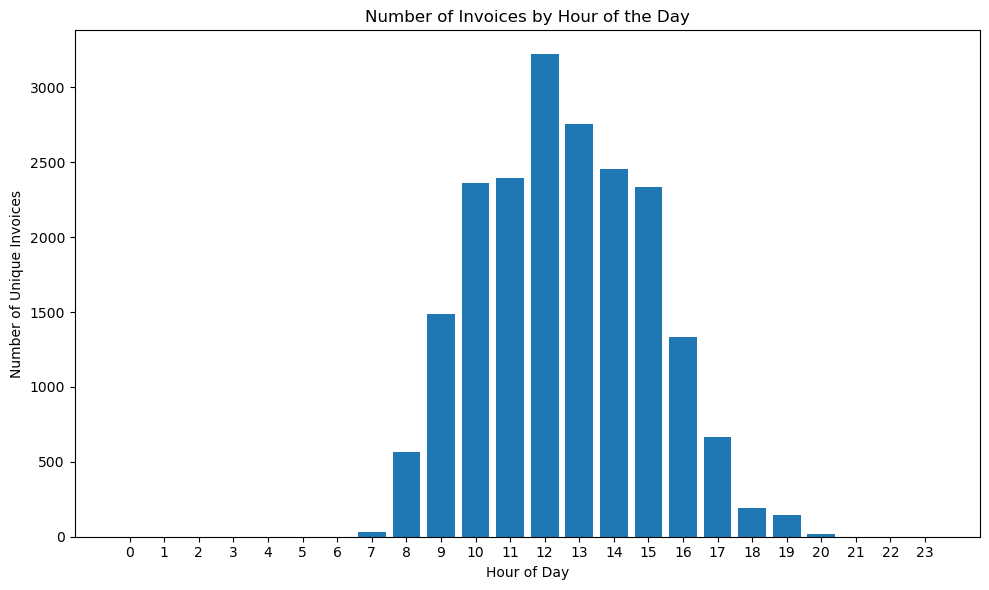

In [103]:
plt.figure(figsize=(10, 6))
plt.bar(hourly_invoice_count['InvoiceHour'], hourly_invoice_count['InvoiceCount'])
plt.title('Number of Invoices by Hour of the Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Unique Invoices')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

### Invoice Activity by Hour Observations

Invoice activity is highest during daytime business hours.

The busiest hour is 12:00, with 3,220 unique invoices. Other active hours include 10:00, 11:00, 13:00, 14:00, and 15:00.

This pattern is similar to the hourly revenue trend, showing that both revenue and invoice activity are concentrated during regular business hours.

However, the highest revenue hour is 10:00, while the highest invoice count occurs at 12:00. This suggests that some hours may have fewer invoices but higher-value orders.

## Average Order Value

Average order value will be analyzed by calculating the total revenue per invoice.

This helps understand the typical value of a customer order and whether the dataset contains unusually large orders.

In [104]:
invoice_summary = (
    df
    .groupby('InvoiceNo')
    .agg(
        InvoiceRevenue=('TotalPrice', 'sum'),
        InvoiceQuantity=('Quantity', 'sum'),
        ProductLines=('StockCode', 'count')
    )
    .reset_index()
)

invoice_summary.head()

,InvoiceNo,InvoiceRevenue,InvoiceQuantity,ProductLines
0,536365,139.12,40,7
1,536366,22.20,12,2
2,536367,278.73,83,12
3,536368,70.05,15,4
4,536369,17.85,3,1


In [105]:
invoice_summary['InvoiceRevenue'].describe()

count     19960.000000
mean        533.171884
std        1780.412288
min           0.380000
25%         151.695000
50%         303.300000
75%         493.462500
max      168469.600000
Name: InvoiceRevenue, dtype: float64

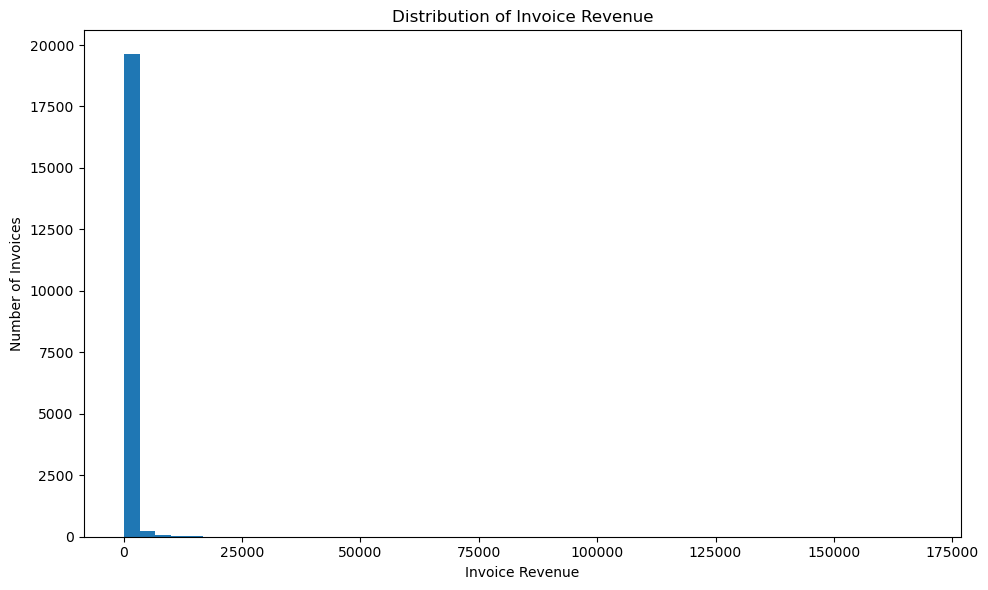

In [106]:
plt.figure(figsize=(10, 6))
plt.hist(invoice_summary['InvoiceRevenue'], bins=50)
plt.title('Distribution of Invoice Revenue')
plt.xlabel('Invoice Revenue')
plt.ylabel('Number of Invoices')
plt.tight_layout()
plt.show()

### Average Order Value Observations

The average invoice revenue is 533.17, while the median invoice revenue is 303.30.

The mean is higher than the median because the dataset contains some very large invoices that pull the average upward.

Most invoices are much smaller than the maximum invoice value of 168,469.60. Because of this extreme value, the invoice revenue distribution is highly right-skewed.

A regular histogram is difficult to read because the largest invoices stretch the x-axis. To make the distribution clearer, a filtered histogram will be created using invoices within the 95th percentile.

In [107]:
invoice_summary['InvoiceRevenue'].quantile([0.50, 0.75, 0.90, 0.95, 0.99])

0.50     303.3000
0.75     493.4625
0.90     938.3910
0.95    1585.9210
0.99    4821.1654
Name: InvoiceRevenue, dtype: float64

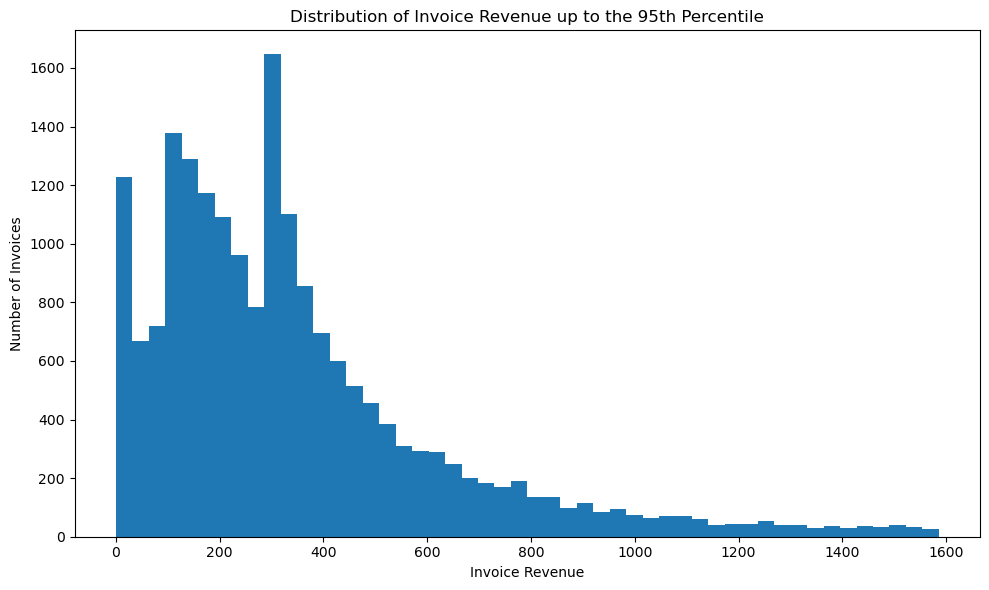

In [108]:
upper_95 = invoice_summary['InvoiceRevenue'].quantile(0.95)

invoice_revenue_filtered = invoice_summary[
    invoice_summary['InvoiceRevenue'] <= upper_95
]

plt.figure(figsize=(10, 6))
plt.hist(invoice_revenue_filtered['InvoiceRevenue'], bins=50)
plt.title('Distribution of Invoice Revenue up to the 95th Percentile')
plt.xlabel('Invoice Revenue')
plt.ylabel('Number of Invoices')
plt.tight_layout()
plt.show()

In [109]:
invoice_summary.sort_values('InvoiceRevenue', ascending=False).head(10)

,InvoiceNo,InvoiceRevenue,InvoiceQuantity,ProductLines
19923,581483,168469.60,80995,1
2116,541431,77183.60,74215,1
16923,574941,52940.94,14149,101
17579,576365,50653.91,13956,99
8693,556444,38970.00,60,1
13545,567423,31698.16,12572,12
8899,556917,22775.93,15049,138
15693,572209,22206.00,1920,7
13537,567381,22104.80,6760,12
11881,563614,21880.44,12196,97


### Invoice Revenue Distribution Observations

The invoice revenue distribution is highly right-skewed.

Most invoices have relatively low revenue values, while a small number of very large invoices increase the average order value.

Because of this skew, the original histogram was difficult to read. A filtered histogram using invoices up to the 95th percentile gives a clearer view of the typical invoice revenue distribution.

The large invoices should not be removed automatically because they may represent valid bulk purchases.

## UK vs Non-UK Revenue Comparison

Since the United Kingdom represents the majority of revenue, sales will be compared between UK and non-UK transactions.

This helps show how much of the business depends on the local UK market compared with international customers.

In [110]:
df['MarketType'] = df['Country'].apply(lambda x: 'UK' if x == 'United Kingdom' else 'Non-UK')

df[['Country', 'MarketType']].head()

,Country,MarketType
0,United Kingdom,UK
1,United Kingdom,UK
2,United Kingdom,UK
3,United Kingdom,UK
4,United Kingdom,UK


In [111]:
market_revenue = (
    df
    .groupby('MarketType')['TotalPrice']
    .sum()
    .reset_index()
)

market_revenue['RevenueShare'] = market_revenue['TotalPrice'] / market_revenue['TotalPrice'].sum() * 100

market_revenue

,MarketType,TotalPrice,RevenueShare
0,Non-UK,1640366.710,15.413922
1,UK,9001744.094,84.586078


In [112]:
market_revenue_formatted = market_revenue.copy()

market_revenue_formatted['TotalPrice'] = market_revenue_formatted['TotalPrice'].apply(lambda x: f"{x:,.2f}")
market_revenue_formatted['RevenueShare'] = market_revenue_formatted['RevenueShare'].apply(lambda x: f"{x:.2f}%")

market_revenue_formatted

,MarketType,TotalPrice,RevenueShare
0,Non-UK,"1,640,366.71",15.41%
1,UK,"9,001,744.09",84.59%


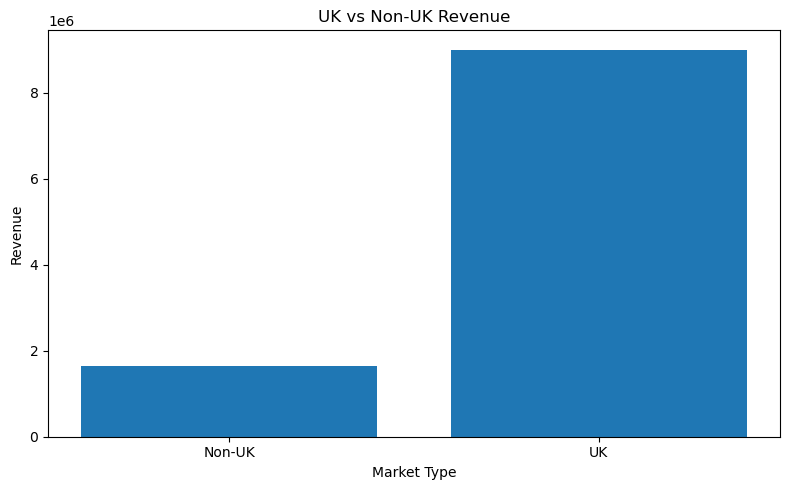

In [113]:
plt.figure(figsize=(8, 5))
plt.bar(market_revenue['MarketType'], market_revenue['TotalPrice'])
plt.title('UK vs Non-UK Revenue')
plt.xlabel('Market Type')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

### UK vs Non-UK Revenue Observations

The United Kingdom generated 9,001,744.09 in revenue, representing 84.59% of total revenue.

Non-UK countries generated 1,640,366.71 in revenue, representing 15.41% of total revenue.

This confirms that the dataset is heavily concentrated in the UK market. While international sales exist, the business depends mainly on UK transactions.

Because of this imbalance, international performance should be analyzed separately from UK performance to avoid the UK dominating all country-level insights.

## Top Non-UK Countries by Revenue

Since the United Kingdom dominates total revenue, non-UK countries will be analyzed separately.

This helps identify the strongest international markets without the UK overwhelming the comparison.

In [115]:
non_uk_country_revenue = (
    df[df['Country'] != 'United Kingdom']
    .groupby('Country')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

non_uk_country_revenue.head(10)

,Country,TotalPrice
0,Netherlands,285446.34
1,EIRE,283140.52
2,Germany,228678.40
3,France,209625.37
4,Australia,138453.81
5,Spain,61558.56
6,Switzerland,57067.60
7,Belgium,41196.34
8,Sweden,38367.83
9,Japan,37416.37


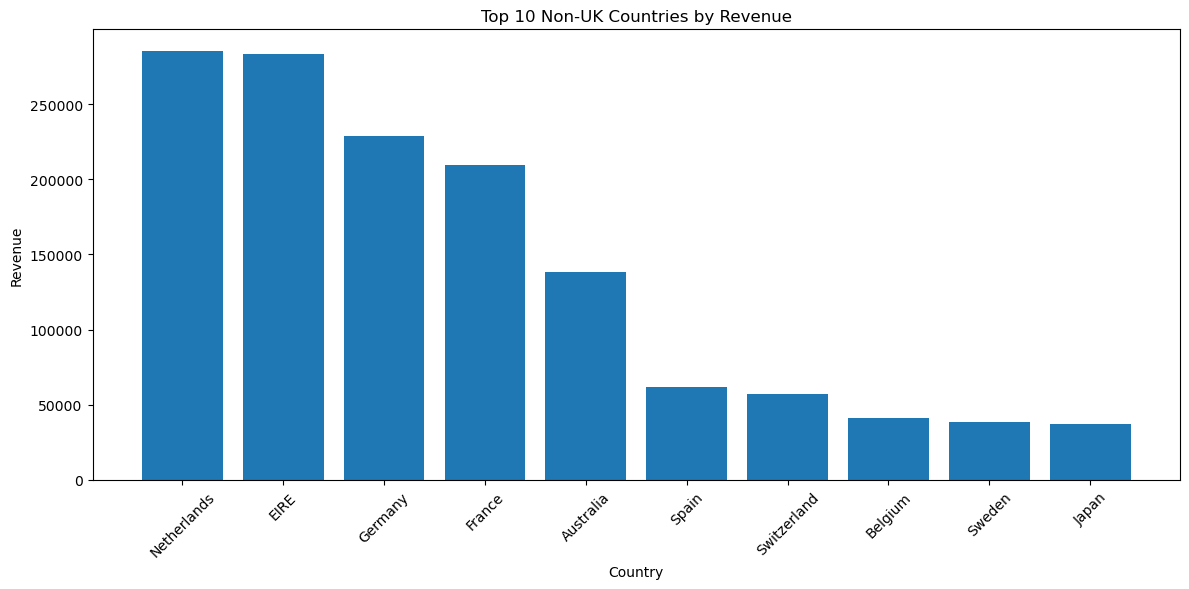

In [116]:
top_10_non_uk_countries = non_uk_country_revenue.head(10)

plt.figure(figsize=(12, 6))
plt.bar(top_10_non_uk_countries['Country'], top_10_non_uk_countries['TotalPrice'])
plt.title('Top 10 Non-UK Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Top Non-UK Countries Observations

After excluding the United Kingdom, the highest revenue-generating international markets are the Netherlands, EIRE, Germany, France, and Australia.

The Netherlands generated 285,446.34 in revenue, followed closely by EIRE with 283,140.52.

Germany and France also contributed strongly, with revenues of 228,678.40 and 209,625.37.

This analysis shows that while the UK dominates the overall dataset, there are still several meaningful international markets worth analyzing separately.

## Saving EDA Summary Tables

Important summary tables from the exploratory analysis will be saved for later use in reports, dashboards, or GitHub documentation.

In [118]:
monthly_revenue.to_csv("../reports/monthly_revenue.csv", index=False)
country_revenue.to_csv("../reports/country_revenue.csv", index=False)
non_uk_country_revenue.to_csv("../reports/non_uk_country_revenue.csv", index=False)
product_performance.to_csv("../reports/product_performance.csv", index=False)
invoice_summary.to_csv("../reports/invoice_summary.csv", index=False)

In [119]:
pd.read_csv("../reports/monthly_revenue.csv").head()

,InvoiceYearMonth,TotalPrice
0,2010-12,821452.730
1,2011-01,689811.610
2,2011-02,522545.560
3,2011-03,716215.260
4,2011-04,536968.491


### EDA Table Export Result

The main exploratory analysis summary tables were saved in the `reports` folder.

These files can be reused later for dashboard creation, README documentation, or final reporting.

# Exploratory Data Analysis Summary

The exploratory data analysis stage examined sales performance, time-based trends, country performance, product performance, and invoice behavior.

Key findings:

- The cleaned dataset contains 524,878 transaction rows.
- Total revenue is 10,642,110.80.
- The dataset includes 19,960 unique invoices, 3,922 unique products, 4,338 customers, and 38 countries.
- Revenue increased strongly toward the end of 2011, with November 2011 generating the highest monthly revenue.
- The United Kingdom dominates the dataset, contributing 84.59% of total revenue.
- Non-UK revenue represents 15.41% of total revenue, with the Netherlands, EIRE, Germany, France, and Australia as the strongest international markets.
- `REGENCY CAKESTAND 3 TIER` is the top product by revenue.
- `WHITE HANGING HEART T-LIGHT HOLDER` appears in the highest number of unique invoices, suggesting strong consistent popularity.
- Some products rank highly because of large bulk purchases, so product performance should be evaluated using revenue, quantity, and invoice count together.
- Sales activity is strongest during weekday business hours, especially between 10:00 and 15:00.
- Invoice revenue is highly right-skewed, meaning most invoices are relatively small while a few large invoices increase the average.

Overall, the dataset shows strong UK market concentration, seasonal revenue growth near the end of the year, and clear differences between high-revenue products, high-volume products, and frequently purchased products.